In [2]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [3]:
(X_train, y_train),(X_test, y_test) = keras.datasets.mnist.load_data()

In [7]:
X_train.shape

(60000, 28, 28)

In [8]:
X_test.shape

(10000, 28, 28)

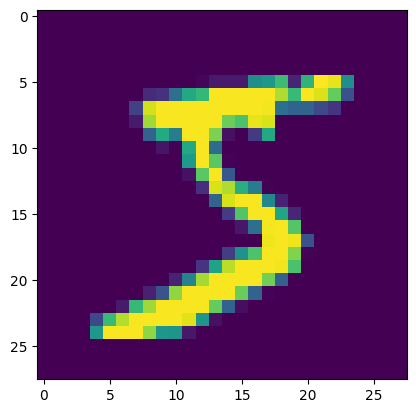

In [12]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [13]:
X_train = X_train/255
X_test = X_test/255

In [74]:
model = Sequential()
model.add(Flatten(input_shape = (28,28)))
model.add(Dense(512,activation='relu'))
model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [75]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_7 (Flatten)         (None, 784)               0         
                                                                 
 dense_13 (Dense)            (None, 512)               401920    
                                                                 
 dense_14 (Dense)            (None, 256)               131328    
                                                                 
 dense_15 (Dense)            (None, 128)               32896     
                                                                 
 dense_16 (Dense)            (None, 32)                4128      
                                                                 
 dense_17 (Dense)            (None, 10)                330       
                                                                 
Total params: 570,602
Trainable params: 570,602
Non-tr

In [76]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [77]:
history = model.fit(X_train,y_train,epochs=25,validation_split =0.2)

Epoch 1/25
1500/1500 [==============================] - 9s 6ms/step - loss: 0.2414 - accuracy: 0.9268 - val_loss: 0.1284 - val_accuracy: 0.9617
Epoch 2/25
1500/1500 [==============================] - 8s 5ms/step - loss: 0.1002 - accuracy: 0.9699 - val_loss: 0.1150 - val_accuracy: 0.9642
Epoch 3/25
1500/1500 [==============================] - 8s 5ms/step - loss: 0.0697 - accuracy: 0.9782 - val_loss: 0.0988 - val_accuracy: 0.9710
Epoch 4/25
1500/1500 [==============================] - 8s 5ms/step - loss: 0.0528 - accuracy: 0.9836 - val_loss: 0.1110 - val_accuracy: 0.9703
Epoch 5/25
1500/1500 [==============================] - 8s 5ms/step - loss: 0.0437 - accuracy: 0.9863 - val_loss: 0.1093 - val_accuracy: 0.9712
Epoch 6/25
1500/1500 [==============================] - 8s 5ms/step - loss: 0.0370 - accuracy: 0.9887 - val_loss: 0.1076 - val_accuracy: 0.9712
Epoch 7/25
1500/1500 [==============================] - 8s 5ms/step - loss: 0.0294 - accuracy: 0.9907 - val_loss: 0.0966 - val_accuracy:

In [78]:
y_prob = model.predict(X_test)

313/313 [==============================] - 1s 3ms/step


In [79]:
y_pred = y_prob.argmax(axis = 1)

In [80]:
from sklearn.metrics import accuracy_score

In [81]:
accuracy_score(y_test,y_pred)

0.9808

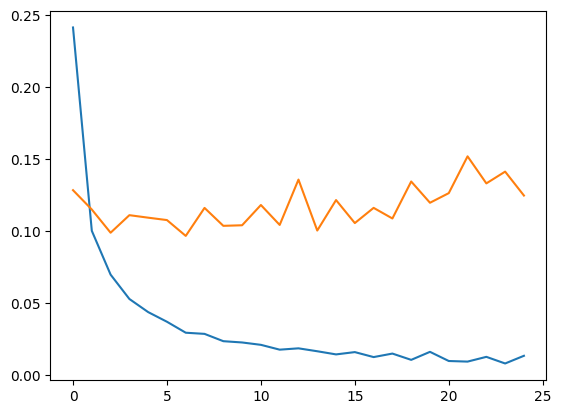

In [82]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

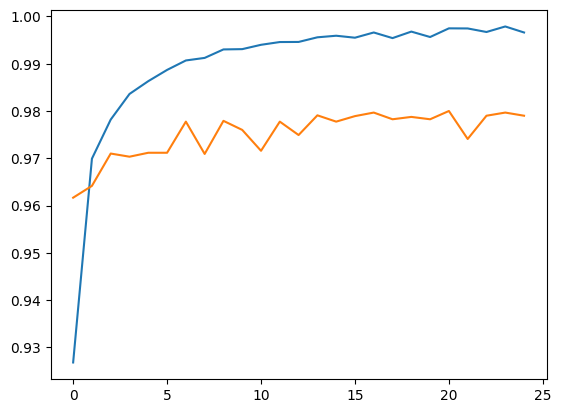

In [83]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

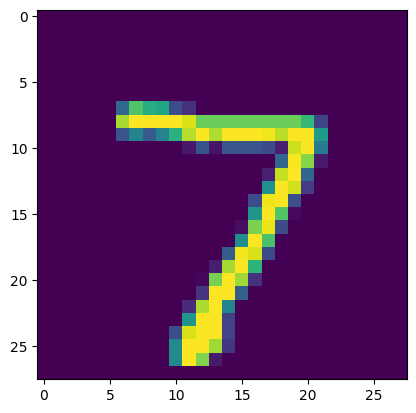

In [84]:
plt.imshow(X_test[0])

In [85]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1)

1/1 [==============================] - 0s 74ms/step


array([7], dtype=int64)